# Flight Delay Analysis
**Dataset:** 2015 US domestic flights (~5.8M rows)  
**Goal:** Predict arrival/departure delays

## 1. Setup & Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('..')

## 2. Data Loading

In [24]:
# Explicit dtypes cut memory usage roughly in half
FLIGHT_DTYPES = {
    # 'YEAR': 'int16', # alles 2015 -> raus
    
    'MONTH': 'int8', 
    'DAY': 'int8', 
    'DAY_OF_WEEK': 'int8',

    'AIRLINE': 'string',

    'FLIGHT_NUMBER': 'int32', 
    
    # 'TAIL_NUMBER' viele missing, irrelevant -> raus
    'ORIGIN_AIRPORT': 'string',
    'DESTINATION_AIRPORT': 'string',

    'SCHEDULED_DEPARTURE': 'string',  
    'DEPARTURE_TIME': 'string', # 1% missing -> raus
    'DEPARTURE_DELAY': 'float32', # 1% missing = DEPARTURE_TIME

    #'TAXI_OUT': 'float32', # 2% viele missing -> raus
    #'WHEELS_OFF': 'string', # 2% viele missing = TAXI_OFF

    'SCHEDULED_TIME': 'float32', # 6 mising
    'ELAPSED_TIME': 'float32', # 2% viele missing
    #'AIR_TIME': 'float32', # 2% viele missing = ELAPSED
    'DISTANCE': 'int32',
    
    #'WHEELS_ON': 'string',  # # 2% viele missing -> raus
    #'TAXI_ON': 'float32', # 2% viele missing = WHEELS_ON

    'SCHEDULED_ARRIVAL' : 'string', 
    'ARRIVAL_TIME': 'string',
    'ARRIVAL_DELAY': 'float32', 

    #'DIVERTED': 'bool', # alle 0 -> raus
    #'CANCELLED': 'bool', # 99.99% sind 0 -> raus

    #'AIRSYSTEM_DELAY'    _> raus
    #'SECURITY_DELAY'     _> raus
    #'AIRLINE_DELAY'      _> raus
    #'LATEAIRCRAFT_DELAY' _> raus
    #'WEATHER_DELAY'      _> raus
}

print('Loading flights.csv (~592 MB) ...')
flights = pd.read_csv(DATA_DIR / 'flights.csv', dtype=FLIGHT_DTYPES)
airlines = pd.read_csv(DATA_DIR / 'airlines.csv')
airports = pd.read_csv(DATA_DIR / 'airports.csv')

# Keep only columns defined in FLIGHT_DTYPES
flights = flights[list(FLIGHT_DTYPES.keys())]
before = len(flights)

# Drop rows with any missing value
flights = flights.dropna()
after = len(flights)

print(f'dropped {before-after} rows...')
print(f'flights: {flights.shape[0]:,} rows × {flights.shape[1]} cols')

Loading flights.csv (~592 MB) ...
dropped 105071 rows...
flights: 5,714,008 rows × 16 cols


## 2a. Datenbereinigung

In [25]:
valid_airlines = set(airlines['IATA_CODE'])
before = len(flights)
invalid_airlines = flights.loc[~flights['AIRLINE'].isin(valid_airlines), 'AIRLINE'].value_counts()
flights = flights[flights['AIRLINE'].isin(valid_airlines)]
print(f'Airline-Filter: {before - len(flights):,} Zeilen entfernt → {len(flights):,} verbleibend')
print('\nEntfernte Airline IATA-Codes:')
print(invalid_airlines.to_string() if len(invalid_airlines) else '  keine')

Airline-Filter: 0 Zeilen entfernt → 5,714,008 verbleibend

Entfernte Airline IATA-Codes:
  keine


In [26]:
valid_airports = set(airports['IATA_CODE'])
before = len(flights)
invalid_origins = flights.loc[~flights['ORIGIN_AIRPORT'].isin(valid_airports), 'ORIGIN_AIRPORT'].value_counts()
invalid_dests = flights.loc[~flights['DESTINATION_AIRPORT'].isin(valid_airports), 'DESTINATION_AIRPORT'].value_counts()
flights = flights[
    flights['ORIGIN_AIRPORT'].isin(valid_airports) &
    flights['DESTINATION_AIRPORT'].isin(valid_airports)
]
print(f'Airport-Filter: {before - len(flights):,} Zeilen entfernt → {len(flights):,} verbleibend')
print('\nEntfernte ORIGIN_AIRPORT-Codes:')
print(invalid_origins.to_string() if len(invalid_origins) else '  keine')
print('\nEntfernte DESTINATION_AIRPORT-Codes:')
print(invalid_dests.to_string() if len(invalid_dests) else '  keine')

Airport-Filter: 482,878 Zeilen entfernt → 5,231,130 verbleibend

Entfernte ORIGIN_AIRPORT-Codes:
ORIGIN_AIRPORT
10397    32509
13930    27566
11298    20586
11292    18077
12892    17628
14771    14094
12266    13091
14107    12884
12889    12649
13487    10552
14747    10361
10721    10091
11433     9882
11057     9537
11618     9508
13204     9006
14869     8738
12953     8447
12478     8255
10821     7991
13232     7598
11278     6759
14679     6184
14100     6065
13303     5929
11259     5873
11697     5753
15304     5125
12191     4681
14057     4539
10693     4450
15016     4295
13796     3994
10423     3871
12173     3761
13495     3646
14893     3598
13198     3536
14908     3524
14831     3457
11042     3202
14492     2984
12264     2979
13342     2631
14683     2594
12339     2361
11066     2178
14122     2122
11193     1903
14843     1858
13830     1814
10140     1805
14635     1756
10800     1753
13891     1734
14027     1734
10529     1705
12451     1701
14524     1628
138

In [27]:
out_path = DATA_DIR / 'flights_cut.csv'
flights.to_csv(out_path, index=False)
print(f'Saved {flights.shape[0]:,} rows × {flights.shape[1]} cols → {out_path}')

Saved 5,231,130 rows × 16 cols → ../flights_cut.csv


## 2b. Train / Validation Split

In [28]:
SPLIT_DTYPES = {
    'MONTH': 'int8', 'DAY': 'int8', 'DAY_OF_WEEK': 'int8',
    'AIRLINE': 'string', 'FLIGHT_NUMBER': 'int32',
    'ORIGIN_AIRPORT': 'string', 'DESTINATION_AIRPORT': 'string',
    'SCHEDULED_DEPARTURE': 'string', 'DEPARTURE_TIME': 'string',
    'DEPARTURE_DELAY': 'float32', 'SCHEDULED_TIME': 'float32',
    'ELAPSED_TIME': 'float32', 'DISTANCE': 'int32',
    'SCHEDULED_ARRIVAL': 'string', 'ARRIVAL_TIME': 'string',
    'ARRIVAL_DELAY': 'float32',
}

train = pd.read_csv(DATA_DIR / 'flights_train.csv', dtype=SPLIT_DTYPES)
val   = pd.read_csv(DATA_DIR / 'flights_val.csv',   dtype=SPLIT_DTYPES)
test  = pd.read_csv(DATA_DIR / 'flights_test.csv',  dtype=SPLIT_DTYPES)

total = len(train) + len(val) + len(test)
print(f'Train: {len(train):,} ({len(train)/total:.0%}) | '
      f'Val:  {len(val):,} ({len(val)/total:.0%}) | '
      f'Test: {len(test):,} ({len(test)/total:.0%})')
train.head(5)

Train: 3,138,678 (60%) | Val:  1,046,226 (20%) | Test: 1,046,226 (20%)


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,IS_DELAYED
0,5,5,2,DL,2121,ANC,SEA,1747,1801,14.0,193.0,193.0,1448,2200,2214,14.0,0
1,8,17,1,WN,1687,LAS,HOU,0535,0530,-5.0,180.0,178.0,1235,1035,1028,-7.0,0
2,2,21,6,DL,1353,ATL,PNS,1100,1054,-6.0,77.0,79.0,271,1117,1113,-4.0,0
3,8,12,3,WN,736,HOU,MSY,1910,1922,12.0,60.0,59.0,302,2010,2021,11.0,0
4,12,6,7,OO,6488,MSP,IAH,1045,1048,3.0,173.0,165.0,1034,1338,1333,-5.0,0


In [29]:
#train = train.sample(frac=0.2, random_state=42).reset_index(drop=True)
#print(f'Train (20% subsample): {len(train):,} rows')

## 2c. Outlier-Entfernung (ARRIVAL_DELAY)

IQR-Methode (3 × IQR) — Grenzen werden **nur aus Trainingsdaten** berechnet, dann auf alle Splits angewendet (kein Datenleck).

In [ ]:
Q1  = train['ARRIVAL_DELAY'].quantile(0.25)
Q3  = train['ARRIVAL_DELAY'].quantile(0.75)
IQR = Q3 - Q1
lo  = Q1 - 3 * IQR
hi  = Q3 + 3 * IQR

print(f'ARRIVAL_DELAY  Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')
print(f'Outlier-Grenzen: [{lo:.1f}, {hi:.1f}] min')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in [
    (axes[0], train['ARRIVAL_DELAY'], 'Vor Outlier-Entfernung'),
    (axes[1], train['ARRIVAL_DELAY'].clip(lo, hi), 'Nach Clipping-Vorschau'),
]:
    ax.hist(data.clip(-150, 400), bins=100, color='steelblue', alpha=0.8, edgecolor='none', density=True)
    ax.axvline(lo, color='red',   lw=1.5, ls='--', label=f'lo={lo:.0f}')
    ax.axvline(hi, color='red',   lw=1.5, ls='--', label=f'hi={hi:.0f}')
    ax.set_title(title)
    ax.set_xlabel('ARRIVAL_DELAY [min]')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

for split_name, df in [('train', train), ('val', val), ('test', test)]:
    before = len(df)
    mask   = df['ARRIVAL_DELAY'].between(lo, hi)
    removed = (~mask).sum()
    pct    = removed / before * 100
    print(f'{split_name:5s}: {removed:,} Outlier ({pct:.2f}%) → {mask.sum():,} verbleibend')

In [ ]:
train = train[train['ARRIVAL_DELAY'].between(lo, hi)].reset_index(drop=True)
val   = val[val['ARRIVAL_DELAY'].between(lo, hi)].reset_index(drop=True)
test  = test[test['ARRIVAL_DELAY'].between(lo, hi)].reset_index(drop=True)

print(f'Nach Outlier-Entfernung:')
print(f'  train: {len(train):,}')
print(f'  val:   {len(val):,}')
print(f'  test:  {len(test):,}')
print(f'  ARRIVAL_DELAY  min={train["ARRIVAL_DELAY"].min():.0f}  max={train["ARRIVAL_DELAY"].max():.0f}')

## 3. Feature Engineering

In [30]:
# Encoder-Maps nur aus Trainingsdaten (kein Datenleck)
airline_codes = sorted(train['AIRLINE'].unique())
airport_codes = sorted(
    set(train['ORIGIN_AIRPORT'].unique()) | set(train['DESTINATION_AIRPORT'].unique())
)
airline_map = {c: i for i, c in enumerate(airline_codes)}
airport_map = {c: i for i, c in enumerate(airport_codes)}

dist_lookup = (
    train.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['DISTANCE']
    .median().to_dict()
)
dist_mean = train['DISTANCE'].mean()

def build_features(df):
    f = df.copy()
    f['AIRLINE_ENC'] = f['AIRLINE'].map(airline_map).fillna(-1).astype('int16')
    f['ORIGIN_ENC']  = f['ORIGIN_AIRPORT'].map(airport_map).fillna(-1).astype('int16')
    f['DEST_ENC']    = f['DESTINATION_AIRPORT'].map(airport_map).fillna(-1).astype('int16')
    f['HOUR']        = f['SCHEDULED_DEPARTURE'].str.zfill(4).str[:2].astype('int8')
    return f

REG_FEATURES = ['HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'DISTANCE']

feat_train = build_features(train)
feat_val   = build_features(val)
feat_test  = build_features(test)

X_train, y_train = feat_train[REG_FEATURES].values, feat_train['ARRIVAL_DELAY'].values
X_val,   y_val   = feat_val[REG_FEATURES].values,   feat_val['ARRIVAL_DELAY'].values
X_test,  y_test  = feat_test[REG_FEATURES].values,  feat_test['ARRIVAL_DELAY'].values

print(f'Features:  {REG_FEATURES}')
print(f'X_train:   {X_train.shape}')
print(f'X_val:     {X_val.shape}')
print(f'X_test:    {X_test.shape}')

Features:  ['HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'DISTANCE']
X_train:   (3138678, 7)
X_val:     (1046226, 7)
X_test:    (1046226, 7)


## 4. Modell-Training (Regression)

In [39]:
import time
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def scale_pipe(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

x_g_model = xgb.XGBRegressor(
    tree_method='hist',
    device='cuda',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

# RandomForest mit max_samples=300_000 (subsampled für Geschwindigkeit)
MODELS = [
    ('Baseline Mean (DummyRegressor)',   DummyRegressor(strategy='mean')),
    ('Baseline Median (DummyRegressor)', DummyRegressor(strategy='median')),
    ('Linear Regression',                scale_pipe(LinearRegression(n_jobs=-1))),
    ('Ridge (α=1)',                      scale_pipe(Ridge(alpha=1.0))),
    ('Lasso (α=0.1)',                    scale_pipe(Lasso(alpha=0.1, max_iter=2000))),
    ('ElasticNet (α=0.1)',               scale_pipe(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000))),
   # ('RandomForest (sub)',               RandomForestRegressor(
   #                                          n_estimators=100, n_jobs=-1, random_state=42,
   #                                          max_samples=300_000, bootstrap=True)),
    ('XGBoost (GPU)',                    x_g_model),
]

results = []
trained_models = {}

for name, model in MODELS:
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    preds_val = model.predict(X_val)
    mae  = mean_absolute_error(y_val, preds_val)
    rms  = rmse(y_val, preds_val)
    r2   = r2_score(y_val, preds_val)
    results.append({
        'Modell':      name,
        'MAE (Val)':   round(mae, 2),
        'RMSE (Val)':  round(rms, 2),
        'R² (Val)':    round(r2, 4),
        'Zeit (s)':    round(elapsed, 1),
    })
    trained_models[name] = model
    print(f'MAE={mae:.1f}  RMSE={rms:.1f}  R²={r2:.4f}  [{elapsed:.0f}s]')

Training Baseline Mean (DummyRegressor)... MAE=21.7  RMSE=39.7  R²=-0.0000  [0s]
Training Baseline Median (DummyRegressor)... MAE=19.5  RMSE=41.0  R²=-0.0620  [0s]
Training Linear Regression... MAE=21.4  RMSE=39.5  R²=0.0126  [1s]
Training Ridge (α=1)... MAE=21.4  RMSE=39.5  R²=0.0126  [0s]
Training Lasso (α=0.1)... MAE=21.4  RMSE=39.5  R²=0.0126  [1s]
Training ElasticNet (α=0.1)... MAE=21.4  RMSE=39.5  R²=0.0126  [1s]
Training XGBoost (GPU)... MAE=20.7  RMSE=38.6  R²=0.0544  [7s]


Die Ankunfsverspätung schon vor dem Flug (also bevor dass man die Abflugsverspätung weiss) vorauszusagen, ist schlecht möglich.
Das Modell erklärt nur etwa 4.2 % der Varianz der Ankunftsverspätungen.
Viele wichtige Ursachen für Verspätungen sind zu diesem Zeitpunkt unbekannt
Dadurch bleibt ein grosser Teil der Varianz grundsätzlich nicht vorhersagbar.

Nützlich wäre vermutlich eher nach dem Abflug die neue Ankunfszeit zu predicten

In [32]:
results_df = pd.DataFrame(results).set_index('Modell').sort_values('MAE (Val)')
print('\n=== Vergleich auf Validierungsdaten ===')
print(results_df.to_string())


=== Vergleich auf Validierungsdaten ===
                                  MAE (Val)  RMSE (Val)  R² (Val)  Zeit (s)
Modell                                                                     
Baseline Median (DummyRegressor)      19.50       40.95   -0.0620       0.0
XGBoost (GPU)                         20.70       38.65    0.0544       5.7
Ridge (α=1)                           21.39       39.49    0.0126       0.4
Linear Regression                     21.39       39.49    0.0126       1.2
ElasticNet (α=0.1)                    21.39       39.49    0.0126       0.7
Lasso (α=0.1)                         21.39       39.49    0.0126       0.6
Baseline Mean (DummyRegressor)        21.67       39.74   -0.0000       0.0


### Normalisierter RMSE (NRMSE)

NRMSE = RMSE / (y_max − y_min) — drückt den Fehler relativ zur Spannweite des Zielwerts aus (0–100 %).

In [33]:
y_range = y_val.max() - y_val.min()

nrmse_df = results_df[['RMSE (Val)']].copy()
nrmse_df['NRMSE (Val) %'] = (nrmse_df['RMSE (Val)'] / y_range * 100).round(3)

print(f'y_val  min={y_val.min():.0f}  max={y_val.max():.0f}  range={y_range:.0f} min')
print()
print('=== RMSE & Normalisierter RMSE auf Validierungsdaten ===')
print(nrmse_df.to_string())

y_val  min=-80  max=1467  range=1547 min

=== RMSE & Normalisierter RMSE auf Validierungsdaten ===
                                  RMSE (Val)  NRMSE (Val) %
Modell                                                     
Baseline Median (DummyRegressor)       40.95          2.647
XGBoost (GPU)                          38.65          2.498
Ridge (α=1)                            39.49          2.553
Linear Regression                      39.49          2.553
ElasticNet (α=0.1)                     39.49          2.553
Lasso (α=0.1)                          39.49          2.553
Baseline Mean (DummyRegressor)         39.74          2.569


### Visualisierung: MAE & RMSE Vergleich

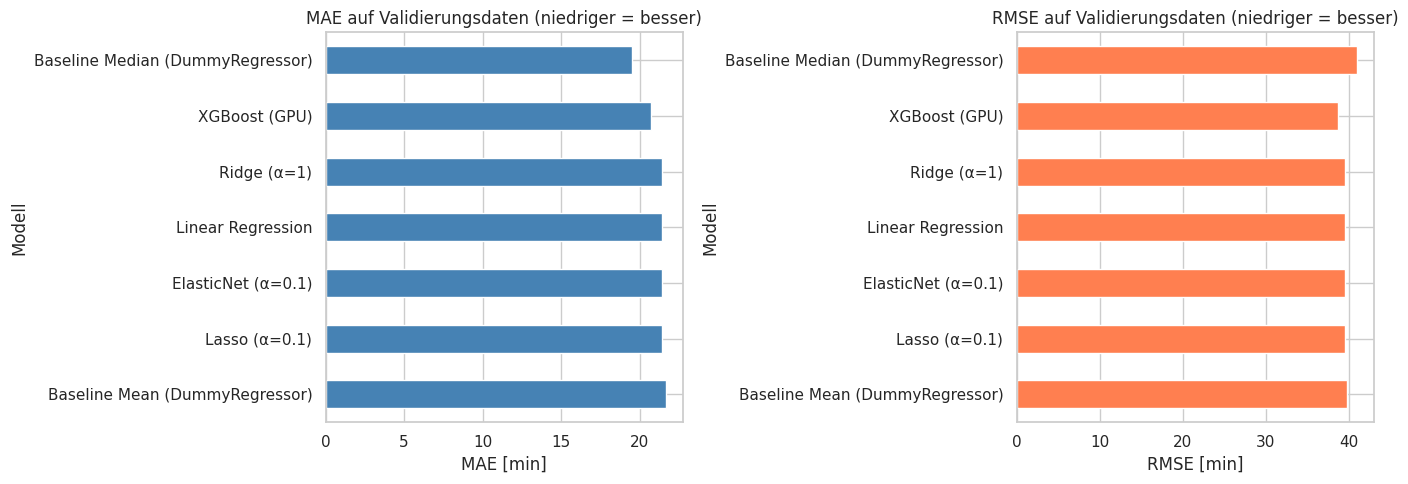

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['MAE (Val)']].plot.barh(ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('MAE auf Validierungsdaten (niedriger = besser)')
axes[0].set_xlabel('MAE [min]')
axes[0].invert_yaxis()

results_df[['RMSE (Val)']].plot.barh(ax=axes[1], legend=False, color='coral')
axes[1].set_title('RMSE auf Validierungsdaten (niedriger = besser)')
axes[1].set_xlabel('RMSE [min]')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4b. 5-fach Cross-Validation

In [35]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in MODELS:
    print(f'CV {name}...', end=' ', flush=True)
    t0 = time.time()
    scores = cross_validate(
        clone(model), X_train, y_train,
        cv=kf,
        scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
    )
    elapsed = time.time() - t0
    mae_scores  = -scores['test_neg_mean_absolute_error']
    rmse_scores = -scores['test_neg_root_mean_squared_error']
    r2_scores   =  scores['test_r2']
    cv_results.append({
        'Modell':    name,
        'MAE Ø':     round(mae_scores.mean(),  2),
        'MAE ±':     round(mae_scores.std(),   3),
        'RMSE Ø':    round(rmse_scores.mean(), 2),
        'RMSE ±':    round(rmse_scores.std(),  3),
        'R² Ø':      round(r2_scores.mean(),   4),
        'R² ±':      round(r2_scores.std(),    4),
        'Zeit (s)':  round(elapsed, 1),
    })
    print(f'MAE={mae_scores.mean():.2f} ± {mae_scores.std():.3f}  '
          f'RMSE={rmse_scores.mean():.2f} ± {rmse_scores.std():.3f}  '
          f'R²={r2_scores.mean():.4f} ± {r2_scores.std():.4f}  [{elapsed:.0f}s]')

cv_df = pd.DataFrame(cv_results).set_index('Modell').sort_values('MAE Ø')
print('\n=== 5-fach Cross-Validation (Trainingsdaten) ===')
print(cv_df.to_string())

CV Baseline Mean (DummyRegressor)... MAE=21.67 ± 0.026  RMSE=39.72 ± 0.176  R²=-0.0000 ± 0.0000  [1s]
CV Baseline Median (DummyRegressor)... MAE=19.50 ± 0.024  RMSE=40.93 ± 0.171  R²=-0.0617 ± 0.0007  [1s]
CV Linear Regression... MAE=21.39 ± 0.020  RMSE=39.47 ± 0.178  R²=0.0127 ± 0.0002  [6s]
CV Ridge (α=1)... MAE=21.39 ± 0.020  RMSE=39.47 ± 0.178  R²=0.0127 ± 0.0002  [4s]
CV Lasso (α=0.1)... MAE=21.39 ± 0.020  RMSE=39.47 ± 0.178  R²=0.0127 ± 0.0002  [4s]
CV ElasticNet (α=0.1)... MAE=21.39 ± 0.020  RMSE=39.47 ± 0.178  R²=0.0126 ± 0.0002  [4s]
CV XGBoost (GPU)... MAE=20.69 ± 0.024  RMSE=38.62 ± 0.183  R²=0.0547 ± 0.0008  [25s]

=== 5-fach Cross-Validation (Trainingsdaten) ===
                                  MAE Ø  MAE ±  RMSE Ø  RMSE ±    R² Ø    R² ±  Zeit (s)
Modell                                                                                  
Baseline Median (DummyRegressor)  19.50  0.024   40.93   0.171 -0.0617  0.0007       0.7
XGBoost (GPU)                     20.69  0.024   

## 5. Vorhersage-Funktion

In [36]:
from datetime import datetime

def predict_delay(date: str, time: str, origin: str, dest: str, airline: str) -> float:
    """
    date:    'YYYY-MM-DD'
    time:    'HHMM'  z.B. '0830'
    origin / dest / airline: IATA-Codes
    Gibt vorhergesagte Ankunftsverspätung in Minuten zurück.
    """
    dt   = datetime.strptime(date, '%Y-%m-%d')
    hour = int(time[:2])
    dist = dist_lookup.get((origin, dest), dist_lookup.get((dest, origin), dist_mean))

    row = np.array([[
        hour,
        dt.month,
        dt.weekday(),
        airline_map.get(airline, -1),
        airport_map.get(origin, -1),
        airport_map.get(dest, -1),
        dist,
    ]])
    return round(float(x_g_model.predict(row)[0]), 1)

examples = [
    ('2015-07-04', '0800', 'LAX', 'JFK', 'AA'),
    ('2015-12-24', '1800', 'ORD', 'ATL', 'WN'),
    ('2015-03-15', '1200', 'SFO', 'SEA', 'AS'),
]
for args in examples:
    delay = predict_delay(*args)
    label = f'+{delay} min (verspätet)' if delay > 0 else f'{delay} min (pünktlich)'
    print(f'{args[4]}  {args[2]}→{args[3]}  {args[0]} {args[1]}  →  {label}')

AA  LAX→JFK  2015-07-04 0800  →  -11.6 min (pünktlich)
WN  ORD→ATL  2015-12-24 1800  →  +22.1 min (verspätet)
AS  SFO→SEA  2015-03-15 1200  →  +4.0 min (verspätet)


## 6. Verteilung der Verspätung

Anteil verspätet (>15 min):  Ankunft 18.5%  |  Abflug 18.2%
ARRIVAL_DELAY   min=-87  max=1898  median=-5.0  mean=4.9
DEPARTURE_DELAY min=-82  max=1878  median=-1.0  mean=9.7


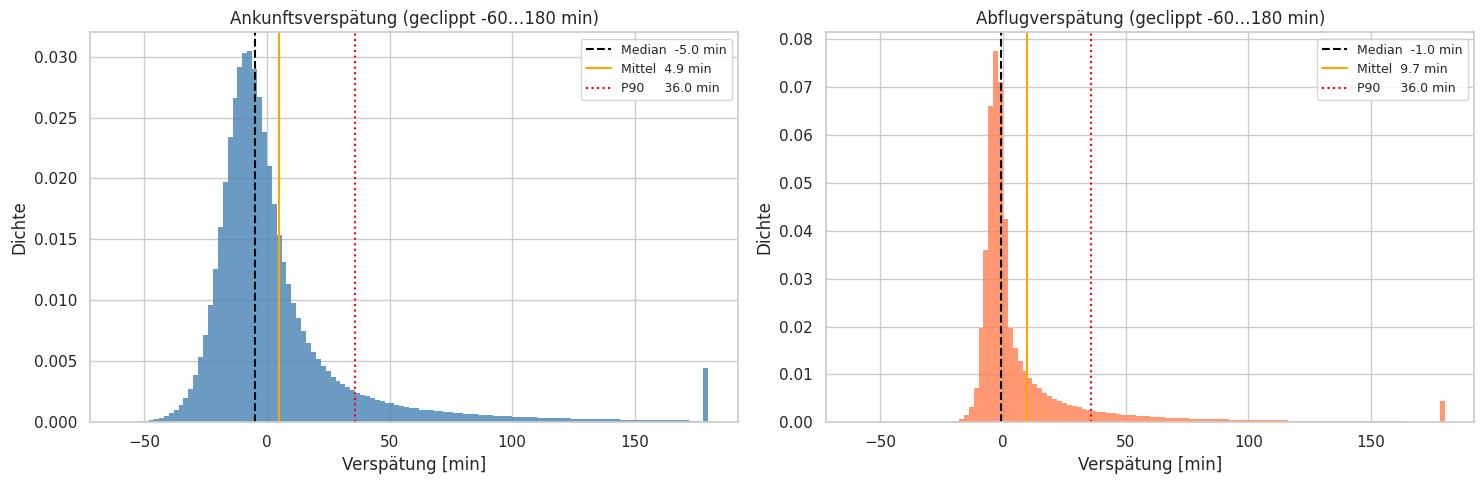

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

CLIP = (-60, 180)  # Extremausreisser ausblenden für bessere Lesbarkeit

for ax, col, color, label in [
    (axes[0], 'ARRIVAL_DELAY',   'steelblue', 'Ankunftsverspätung'),
    (axes[1], 'DEPARTURE_DELAY', 'coral',     'Abflugverspätung'),
]:
    data = train[col].clip(*CLIP)
    ax.hist(data, bins=120, color=color, alpha=0.8, edgecolor='none', density=True)

    med  = train[col].median()
    mean = train[col].mean()
    p90  = train[col].quantile(0.90)
    ax.axvline(med,  color='black',  lw=1.5, ls='--', label=f'Median  {med:.1f} min')
    ax.axvline(mean, color='orange', lw=1.5, ls='-',  label=f'Mittel  {mean:.1f} min')
    ax.axvline(p90,  color='red',    lw=1.5, ls=':',  label=f'P90     {p90:.1f} min')

    ax.set_title(f'{label} (geclippt {CLIP[0]}…{CLIP[1]} min)')
    ax.set_xlabel('Verspätung [min]')
    ax.set_ylabel('Dichte')
    ax.legend(fontsize=9)

pct_late_arr = (train['ARRIVAL_DELAY'] > 15).mean() * 100
pct_late_dep = (train['DEPARTURE_DELAY'] > 15).mean() * 100
print(f'Anteil verspätet (>15 min):  Ankunft {pct_late_arr:.1f}%  |  Abflug {pct_late_dep:.1f}%')
print(f'ARRIVAL_DELAY   min={train["ARRIVAL_DELAY"].min():.0f}  max={train["ARRIVAL_DELAY"].max():.0f}  '
      f'median={train["ARRIVAL_DELAY"].median():.1f}  mean={train["ARRIVAL_DELAY"].mean():.1f}')
print(f'DEPARTURE_DELAY min={train["DEPARTURE_DELAY"].min():.0f}  max={train["DEPARTURE_DELAY"].max():.0f}  '
      f'median={train["DEPARTURE_DELAY"].median():.1f}  mean={train["DEPARTURE_DELAY"].mean():.1f}')

plt.tight_layout()
plt.show()